In [3]:
%reload_ext autoreload
%autoreload 2

#load libraries
import glob
import os
import pandas as pd
from datetime import datetime
import numpy as np
import main_funcs as mfun

import plot_funcs as pfun
import utils_funcs as utils # utils is from Vape - catcher file: 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pickle
import psychofit.psychofit as psy

# Get the data info
pfun.set_figure()


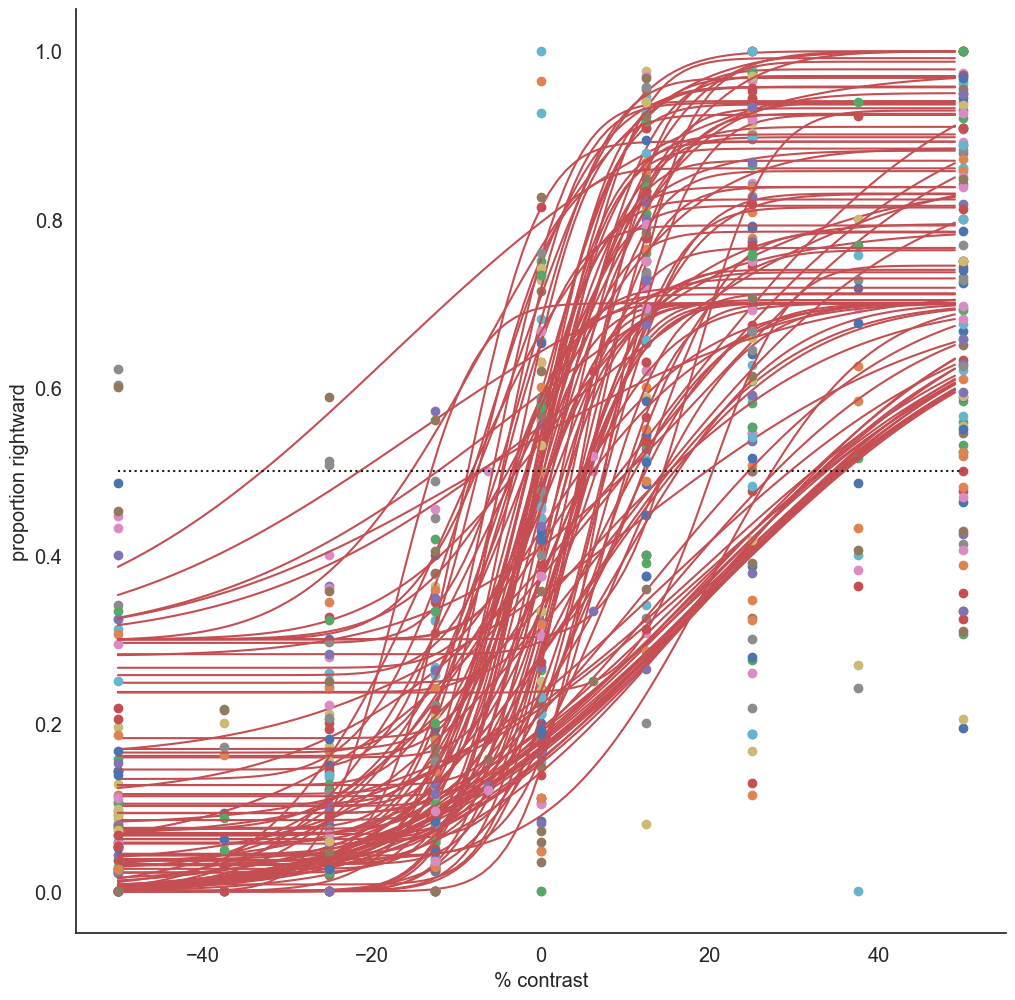

In [ ]:
repo_analysis_path = r'C:/Users/Huriye/Documents/code/sideBiasLateralisation/analysis'
info = pickle.load(open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info2.pkl'), 'rb'))

results = []  # collect summary rows

# for each recording session, check if responsive neuron file exists in the analysis folder
for ind, recordingDate in enumerate(info.recordingList.recordingDate):
    if ind >-90:
        pathname = info.recordingList.analysispathname[ind]
        sessionName = info.recordingList.sessionName[ind]

        # ---- load csv file ----
        filenameCSV = os.path.join(pathname, f"{sessionName}_CorrectedEventTimes.csv")
        if not os.path.exists(filenameCSV):
            print(f"[SKIP] Missing CSV: {filenameCSV}")
            continue

        df = pd.read_csv(filenameCSV)

        # ---- calculate response time ----
        # RT = choiceCompleteTime - choiceStartTime
        df["responseTime"] = mfun.compute_response_time(df)

        # ---- calculate the cut off trials in the session - exclude motivation loss trials ----
        end_trial_number, end_trial_row_index = mfun.find_motivation_cutoff_trial(df, rt_col="responseTime", factor=4.0)

        if end_trial_number is None:
            # if no cutoff detected, keep all trials
            df_motiv = df.copy()
            cutoff_note = "no_cutoff"
        else:
            # "give me that trial as the end trial"
            # Usually you exclude that trial and all after it as "unmotivated".
            # So keep trials strictly BEFORE the end_trial_row_index.
            df_motiv = df.iloc[:end_trial_row_index].copy()
            cutoff_note = f"cutoff_at_trial_{end_trial_number}"


        # ---- calculate the bias after removing unmotivated trials ----
        bias = mfun.compute_zero_stim_bias(df_motiv)

        
        ##### plot psychometric curve
        pars, L, data, g = mfun.fit_psy_AllContrasts(df_motiv)
        # lets plot the data
        xx = data [0, :]
        nn = data [1, :]
        dd = data [2, :]
        plt.plot(xx, dd, 'bo')
        plt.plot(np.arange(-50, 50), psy.erf_psycho_2gammas( pars, np.arange(-50, 50) ), color = 'b')
        plt.plot((-50, 50), (.5, .5), 'k:')
        plt.xlim([-55, 55])
        plt.xlabel('% contrast')
        plt.ylabel('proportion rightward')


        # xfit = np.arange(-50, 51)
        # pars_opt = np.array(pars, dtype=float).copy()
        # pars_opt[0] = 0.0        # bias = 0 (center at 0%)
        # pars_opt[2:] = 0.0       # remove lapses (and any extra gamma params)

        # plt.plot(xfit, psy.erf_psycho_2gammas(pars_opt, xfit), 'k--', linewidth=2, label='Optimal')

        # plt.xlabel('% contrast')
        # plt.ylabel('Proportion rightward')
        # plt.legend()
        # plt.tight_layout()
        # plt.show()
        # # save in analysis folder
        plot_filename = os.path.join(info.figsPath, f"{sessionName}_All_psychometric_curve.png")
        plt.savefig(plot_filename)
        plt.close()

        #lets add them as a new column to the info.recordingList 

        info.recordingList.loc[ind, "end_trial_number"] = end_trial_number if end_trial_number is not None else np.nan

        info.recordingList.loc[ind, "bias"] = bias
        info.recordingList.loc[ind, "biasPsycho_bias"] = pars[0]
        info.recordingList.loc[ind, "biasPsycho_slope"] = pars[2]
        info.recordingList.loc[ind, "cutoff_note"] = cutoff_note

info.recordingList['imagingDataExtracted']=1


In [14]:
pathname

'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-05-22_MBL015_1\\'

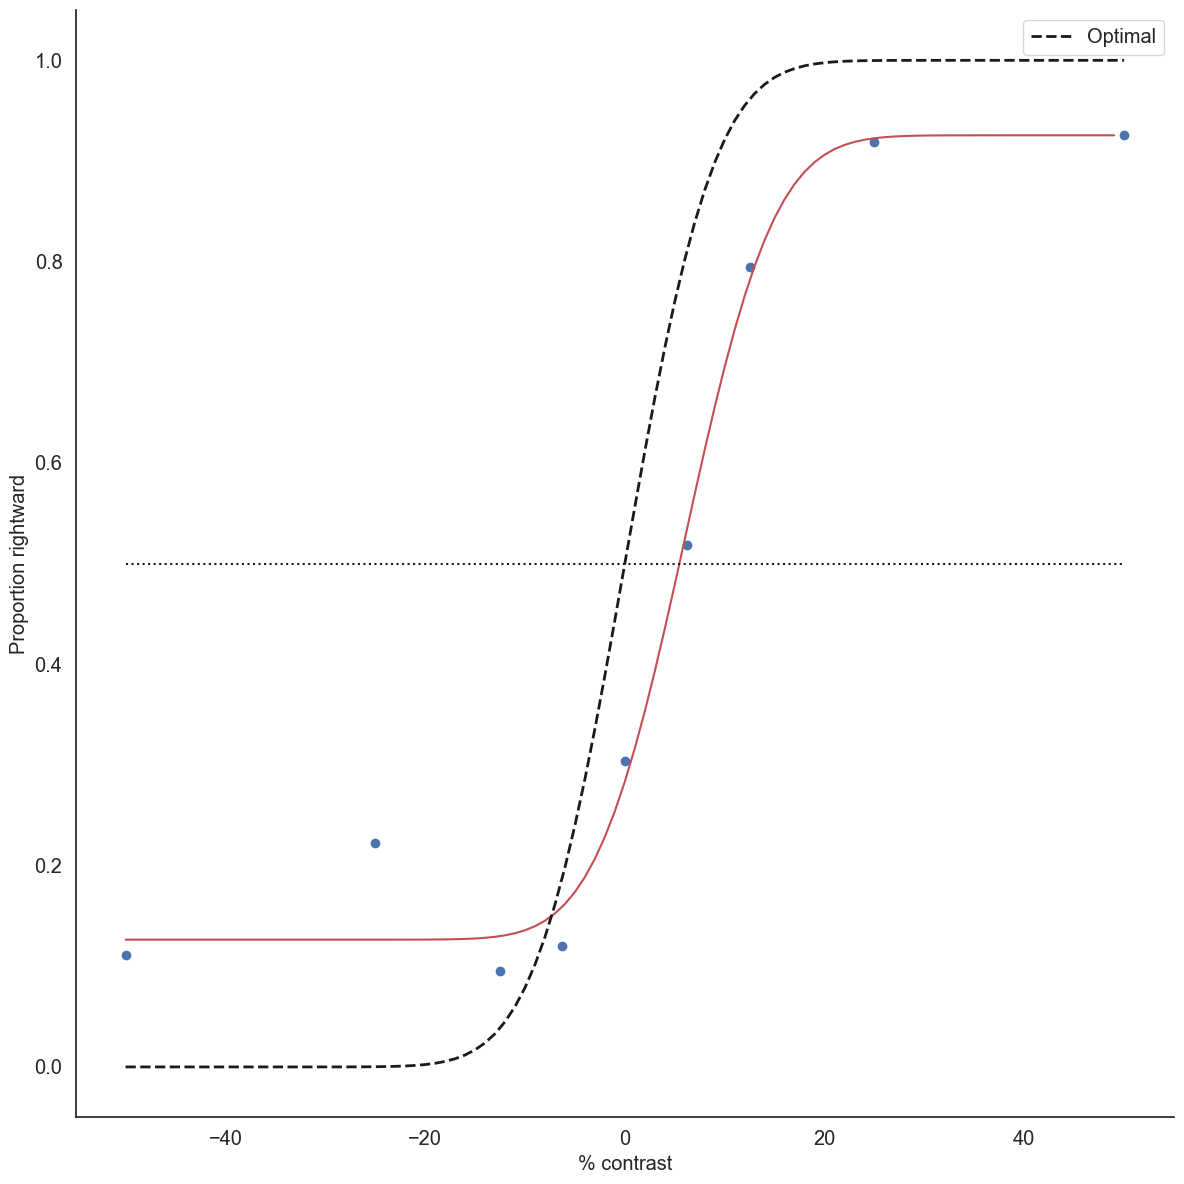

In [10]:


pars, L, data, g = mfun.fit_psy_AllContrasts(df_motiv)
# lets plot the data
xx = data [0, :]
nn = data [1, :]
dd = data [2, :]
plt.plot(xx, dd, 'o')
plt.plot(np.arange(-50, 50), psy.erf_psycho_2gammas( pars, np.arange(-50, 50) ), color = 'r')
plt.plot((-50, 50), (.5, .5), 'k:')
plt.xlabel('% contrast')
plt.ylabel('proportion rightward')


xfit = np.arange(-50, 51)
pars_opt = np.array(pars, dtype=float).copy()
pars_opt[0] = 0.0        # bias = 0 (center at 0%)
pars_opt[2:] = 0.0       # remove lapses (and any extra gamma params)

plt.plot(xfit, psy.erf_psycho_2gammas(pars_opt, xfit), 'k--', linewidth=2, label='Optimal')

plt.xlabel('% contrast')
plt.ylabel('Proportion rightward')
plt.legend()
plt.tight_layout()
plt.show()

Number of sessions with bias >=0.25: 7
Number of sessions with bias <=-0.25: 38
Error processing session 2025-08-14_1_HAT010: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-08-14_HAT010_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'
Error processing session 2025-11-29_1_MAT058: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-11-29_MAT058_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'
Error processing session 2025-12-05_1_MAT058: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-12-05_MAT058_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'


c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:1560: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:1560: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Error processing session 2025-08-05_1_HAT010: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-08-05_HAT010_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'
Error processing session 2025-08-15_1_HAT010: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-08-15_HAT010_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'
Error processing session 2025-11-28_1_MAT058: [Errno 2] No such file or directory: 'C:\\Users\\Huriye\\Documents\\code\\sideBiasLateralisation\\analysis\\2025-11-28_MAT058_1\\responsive_neurons\\imaging-dffTrace_mean_zscored.pkl'


c:\Users\Huriye\Documents\code\sideBiasLateralisation\plot_funcs.py:1560: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


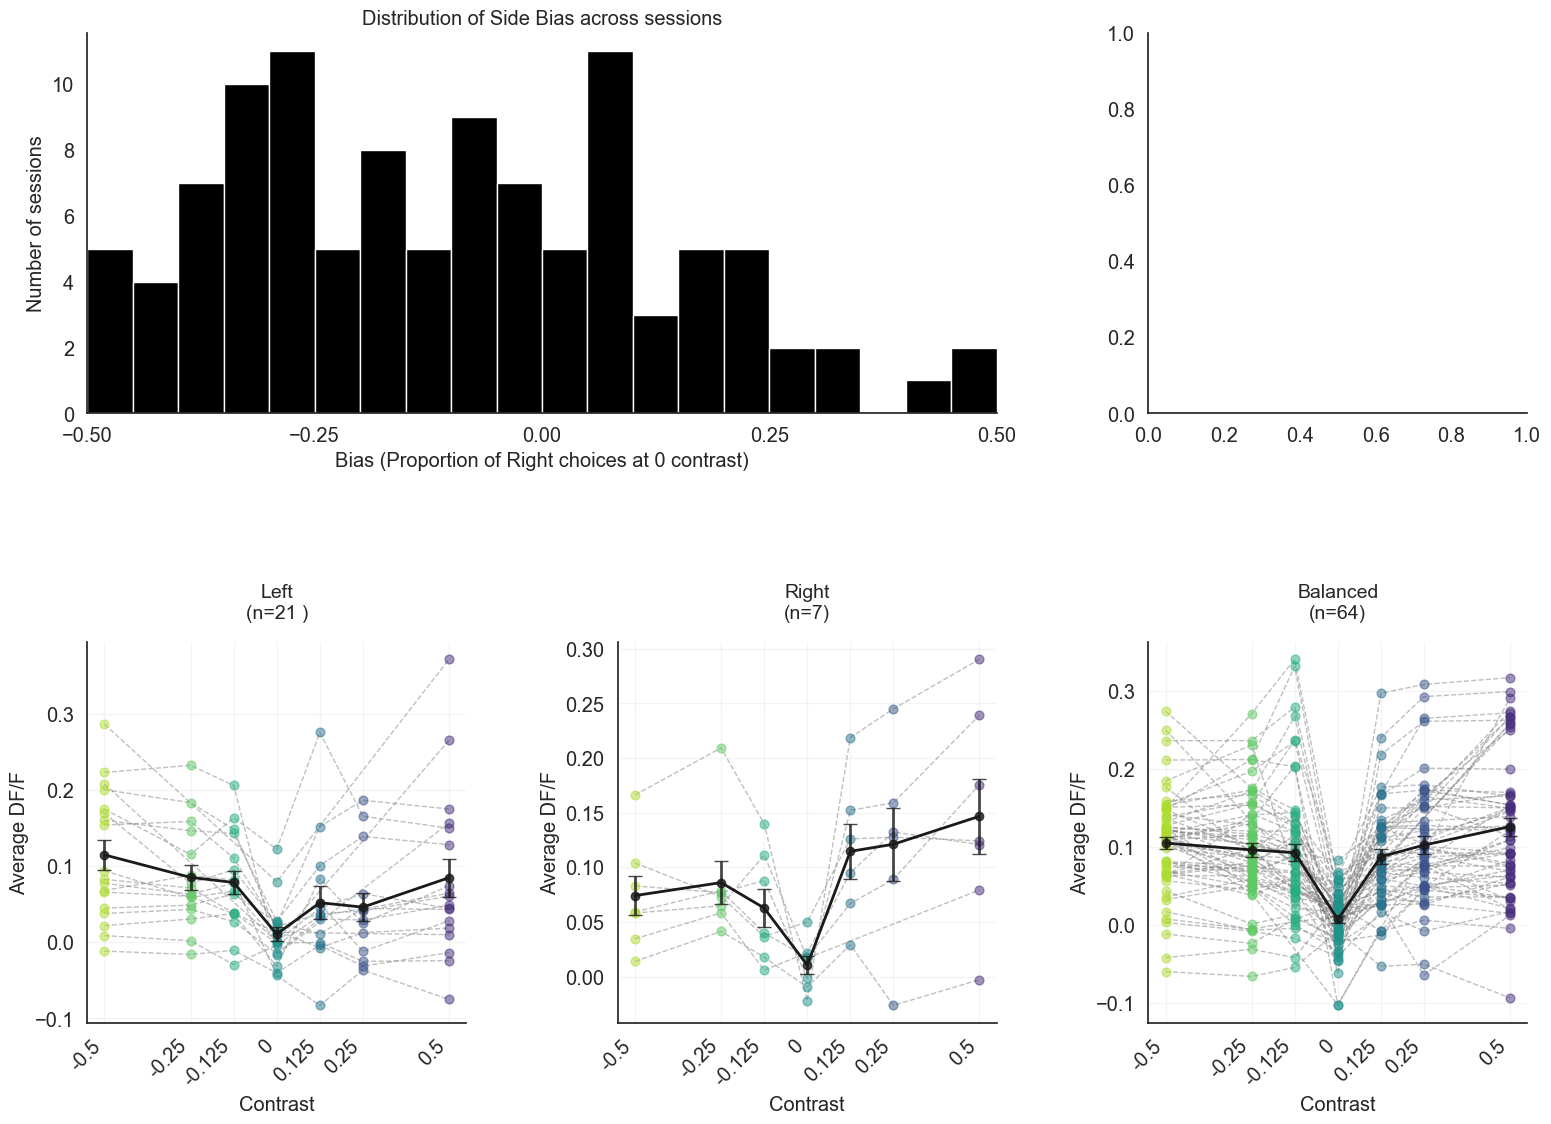

In [106]:
#get info for below 0.25 bias sessions
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=3, nrows=2, bottom=0, top=0.9, left=0.05, right=0.95,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(6)}

# Plot the histogram for bias
ax_contrast[0].remove()                       # remove old axis in slot 0
ax_contrast[1].remove()                       # remove old axis in slot 0
ax_contrast[0] = fig.add_subplot(gs_contrast[0, 0:2])  # span first two slots
ax_contrast[0].hist(info.recordingList['bias'].dropna(), bins=20, color = 'black')
ax_contrast[0].set_ylabel('Number of sessions')
ax_contrast[0].set_xlabel('Bias (Proportion of Right choices at 0 contrast)')
ax_contrast[0].set_title('Distribution of Side Bias across sessions')
ax_contrast[0].set_xlim([-0.5, 0.5])
ax_contrast[0].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])

# get the total number of recording for 0.75 above + 0.25 below
num_high_bias = len(info.recordingList[info.recordingList['bias'] >= 0.25])
num_low_bias = len(info.recordingList[info.recordingList['bias'] <= -0.25])
print(f'Number of sessions with bias >=0.25: {num_high_bias}')  
print(f'Number of sessions with bias <=-0.25: {num_low_bias}')

# Plot the mean dF/F by contrast for low bias sessions

infoSelected = info.recordingList[(info.recordingList['bias'] <= -0.25) &
                                  (info.recordingList['performance'] >=75)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, 1],
    subfolder='responsive_neurons',
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[3],
    title = 'Left' + '\n(n=' + str(nSes[0]) +' )',
)

# Plot the mean dF/F by contrast for low bias sessions

infoSelected = info.recordingList[(info.recordingList['bias'] >= 0.25) &
                                  (info.recordingList['performance'] >=0)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, 1],
    subfolder='responsive_neurons',
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[4],
    title = 'Right' + '\n(n=' + str(nSes[0]) +')',
)


# Plot the mean dF/F by contrast for low bias sessions

infoSelected = info.recordingList[(info.recordingList['bias'] <= 0.25) & (info.recordingList['bias'] >= -0.25) &
                                  (info.recordingList['performance'] >=0)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, 1],
    subfolder='responsive_neurons',
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[5],
    title = 'Balanced' + '\n(n=' + str(nSes[0]) +')',
)

pfun.save_figure(f'DFF-Contrast_Main', info.figsPath)



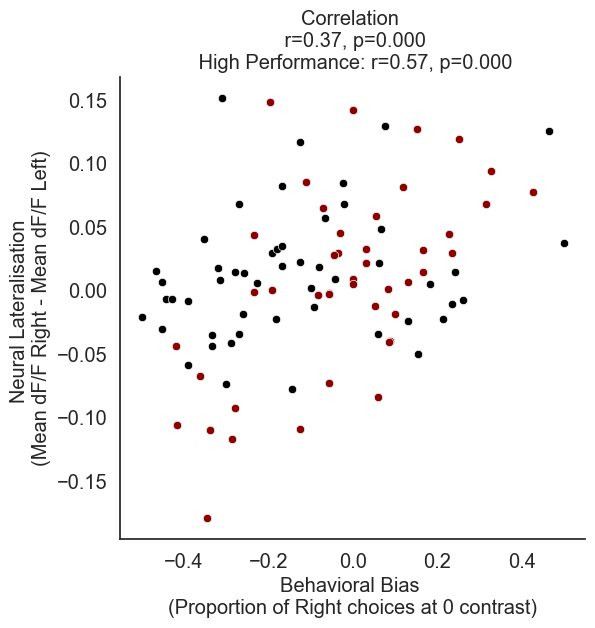

In [105]:
df_cdiff = mfun.get_mean_dff_by_contrast_diff_df(info.recordingList, event_type="stimulus")

df = df_cdiff.copy()
df["side"] = np.where(
    df["cDiff"] > 0, "Right",
    np.where(df["cDiff"] < 0, "Left", None)  # <-- None, not np.nan
)

out = (
    df.groupby(["animal", "session", "recordingDate",'bias', 'performance',"side"], as_index=False)
      .agg(mean_dff=("mean_dff", "mean"))
      .pivot_table(
          index=["animal", "session", "recordingDate", 'bias', 'performance'],
          columns="side",
          values="mean_dff",
      )
      .reset_index()
)

df = out.copy()
df['cDiff'] = df['Right'] - df['Left']

pfun.set_figure()
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=df, x='bias', y='cDiff', ax=ax, color='black')
ax.set_xlabel('Behavioral Bias \n(Proportion of Right choices at 0 contrast)')
ax.set_ylabel('Neural Lateralisation \n(Mean dF/F Right - Mean dF/F Left)')
# add stats & line
from scipy.stats import pearsonr
r, p = pearsonr(df['bias'], df['cDiff'])
#sns.regplot(data=df, x='bias', y='cDiff', ax=ax, scatter=False, color='red', line_kws={'linewidth':1})
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}')
pfun.save_figure(f'BehavioralBias_vs_NeuralLateralisation', info.figsPath)

# add only really good performance
df_highperf = df[df['performance'] >=85]
sns.scatterplot(data=df_highperf, x='bias', y='cDiff', ax=ax, color='darkred')
r2, p2 = pearsonr(df_highperf['bias'], df_highperf['cDiff'])
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}' + f'\n High Performance: r={r2:.2f}, p={p2:.3f}')
pfun.save_figure(f'BehavioralBias_vs_NeuralLateralisation_highPerf', info.figsPath)


In [92]:
out

side,animal,session,recordingDate,bias,Left,Right
0,HA011,2025-08-31_1_HA011,2025-08-31,0.062500,-0.004011,0.017743
1,HA011,2025-09-02_1_HA011,2025-09-02,-0.333333,0.048860,0.013926
2,HA011,2025-09-03_1_HA011,2025-09-03,-0.125000,0.087428,0.110325
3,HA011,2025-09-04_1_HA011,2025-09-04,-0.388889,0.257660,0.199291
4,HA011,2025-09-07_1_HA011,2025-09-07,0.083333,0.042561,0.043539
...,...,...,...,...,...,...
90,MBL014,2025-06-21_1_MBL014,2025-06-21,0.076923,0.124623,0.254630
91,MBL015,2025-05-16_1_MBL015,2025-05-16,-0.362069,0.099755,0.032624
92,MBL015,2025-05-20_1_MBL015,2025-05-20,-0.418919,0.150192,0.106579
93,MBL015,2025-05-21_1_MBL015,2025-05-21,-0.428571,0.148747,0.142394


C:\Users\Huriye\AppData\Local\Temp\ipykernel_25772\3864192251.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 'sem')` for the same effect.

  sns.pointplot(data=df_cdiff, x='cDiff', y='mean_dff', ci='sem', join=False, color='black', markers='o', scale=1.5)


TypeError: `errorbar` must be a callable, string, or (string, number) tuple

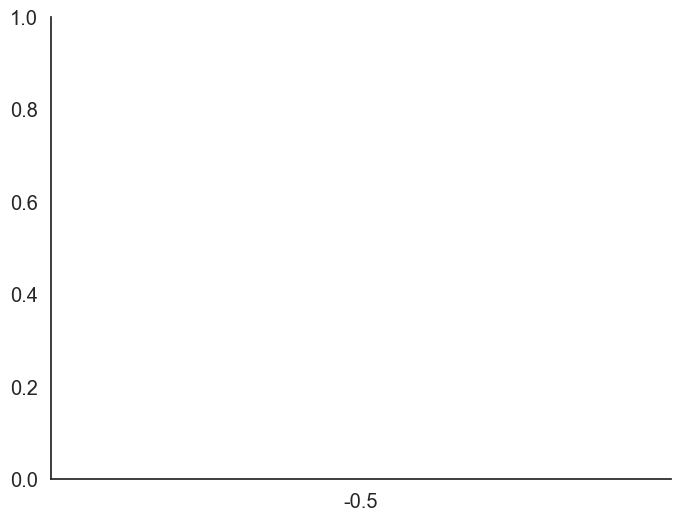

In [84]:
# lets  plot the difference in mean dF/F by contrast difference
pfun.set_figure()
fig, ax = plt.subplots(figsize=(8,6))
sns.pointplot(data=df_cdiff, x='cDiff', y='mean_dff', ci='sem', join=False, color='black', markers='o', scale=1.5)















In [ ]:
# List of sessions to filter
specific_expRefs = ['2025-05-22_1_MBL015', '2025-05-20_1_MBL015', '2025-05-16_1_MBL015', '2025-05-14_1_MBL015']
# specific_expRefs = ['2025-05-20_1_MBL015']
# Filter the recording list to include only the specified sessions
info.recordingList = info.recordingList[info.recordingList['sessionName'].isin(specific_expRefs)].reset_index(drop=True)
info.recordingList

In [ ]:
# Plot combined psychometric
pfun.plot_combined_psychometric(
    info=info,
    save_path=None  # Will use default path if None
)

# Plot combined response time
pfun.plot_combined_response_time(
    info=info,
    analysis_path=analysis_path,
    save_path=None  # Will use default path if None
)

In [ ]:
# plot neural activity across sessions
# analysis_params = ['ipsi_recside', 'contra_recside']
analysis_params = ['ipsi_bias', 'contra_bias']
# Only responsive neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=True)

# All neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=False)

In [ ]:
# Plot combined dff mean by contrast
use_responsive_only = True  # Change to False to use all neurons
zscoreRun = True  # Change to False to use raw data

# Call the function
pfun.plot_combined_dff_mean_by_contrast(
    info=info,
    zscoreRun=zscoreRun,
    use_responsive_only=use_responsive_only,
    save_path=None  # Will use default path if None
)